# 00 — Data Audit

**Author:** Henry Otsyula
**Challenge:** Bias Bounty Mapping Equity Challenge (Zindi)
**Stage:** Stage 2, Step 7

This notebook is the Stage 2 deliverable that turns the audit work done in Steps 1&ndash;6 into a
single, reproducible, reviewable artifact. It does not repeat that work from scratch &mdash; it
re-runs it live against the bucket, verifies the fixes already made to `src/schemas.py` are still
correct, and then goes deeper than the audit script itself did, in four directions the script
deliberately left out of its own scope:

1. **Live, full re-run** of the Stage 2 Step 5/6 audit across all four regions, so this notebook's
   pass/fail table is generated fresh, not copied from `docs/audit_findings.csv`.
2. **A GEOID reconciliation check** between each region's raw strata `census-tracts` table and its
   authoritative scored-tract list (`reference/<region>/<region>-sample-submission.csv`) &mdash; the
   empirical basis for a hard rule the rest of this project must follow: any script that builds the
   final submission must filter to the sample-submission GEOID list, never assume the raw strata
   table already matches it.
3. **A geometry-defect deep dive** on Microsoft buildings' small residual invalid-geometry count
   (found in the Step 6 run), characterizing *what* is wrong with those geometries, not just how
   many there are.
4. **A null-rate deep dive** across every layer and region, visualizing the Overture buildings
   `subtype`/`class` regional gradient that is now a logged Best Bias Discovery candidate
   (`docs/bias_discovery.md`), and confirming the HIFLD `admintype` and TIGER `FULLNAME`/`RTTYP`
   findings.

Every check in this notebook either loads real data from the live bucket (no credentials required)
or is proven first against a tiny synthetic fixture built in-notebook, matching the same
build-then-verify discipline used throughout Stage 2. Run top to bottom; each section prints or
displays what it found before moving on, and the notebook is self-checking &mdash; look for an
`assert` or a printed PASS/FAIL line at the end of each section rather than eyeballing tables for
correctness.

**Prerequisites**: `src/schemas.py`, `src/io.py`, `src/geometry.py`, `src/config.py`, and
`scripts/audit/audit_bucket.py` all exist and reflect the final state reached at the end of Step 6
(bbox tolerated on four strict schemas, Overture buildings' `subtype` nullable, `validate_layer`
using `lazy=True`, Microsoft buildings' confidence tolerating the documented `-1.0` placeholder,
every relevant `Check` bounded with `n_failure_cases`). Run with the `bias-bounty` conda
environment (`conda create -n bias-bounty python=3.11` then `pip install -r requirements.txt`, per
`docs/reproducibility.md`) so package versions match what every fixture and self-check in this
notebook was built against.

## 0. Setup

Repository root is inserted onto `sys.path` the same way `scripts/audit/audit_bucket.py` does, so
`import src...` resolves regardless of which directory Jupyter was launched from. The audit
script's own pure functions are imported and reused rather than re-implemented here &mdash; they
are already unit-tested (`tests/test_audit_bucket.py`), and duplicating their logic in the notebook
would be a second, unverified copy of the same statistics.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.validation import explain_validity
from tqdm.auto import tqdm

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src").exists(), (
    f"Could not locate the repository root (a directory containing 'src/') from {Path.cwd()!r}. "
    "Run this notebook from the repository root or from notebooks/, its only supported locations."
)
for p in (str(REPO_ROOT), str(REPO_ROOT / "scripts" / "audit")):
    if p not in sys.path:
        sys.path.insert(0, p)

from src.config import LAYER_MICROSOFT_BUILDINGS, REGIONS, STRATA_KEY_COLUMN  # noqa: E402
from src.io import load_reference_layer, load_sample_submission, load_strata_table  # noqa: E402
from src.schemas import (  # noqa: E402
    MICROSOFT_BUILDINGS_SCHEMA,
    OVERTURE_POIS_SCHEMA,
    SchemaValidationError,
)

import audit_bucket as ab  # noqa: E402 — scripts/audit/audit_bucket.py, added to sys.path above

REFERENCE_LAYERS = ab.REFERENCE_LAYERS
print(f"Repository root: {REPO_ROOT}")
print(f"Regions: {REGIONS}")
print(f"Reference layers audited: {REFERENCE_LAYERS}")

Repository root: D:\PROJECTS\bias-bounty-mapping-equity
Regions: ['maricopa-az', 'northern-ca', 'eastern-ok', 'south-central-tx']
Reference layers audited: ['census-cbp', 'census-tiger-roads', 'hifld-ems-stations', 'hifld-fire-stations', 'hifld-hospitals', 'hifld-schools', 'microsoft-buildings', 'overture-buildings', 'overture-pois', 'overture-roads']


d:\CONDA\conda_envs\bias-bounty\Lib\site-packages\pandera\_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


## 1. Schema-fix regression proof (no network required)

Before re-running the full live audit, this section proves &mdash; in-memory, against tiny
hand-built fixtures, with no bucket access &mdash; that the four real schema bugs found and fixed
during Steps 5&ndash;6 are still fixed. This is the fastest possible early-warning check: if any of
these six assertions fails, `src/schemas.py` has regressed and there is no point spending minutes
re-running the full live audit below until it is fixed again.

The four real bugs, for reference (full detail in `docs/data_manifest.md` Section 4.8):

1. `bbox` was declared required on four `strict=True` schemas; the real files never carry it.
2. Overture buildings' `subtype` was declared non-nullable; real data has nulls in every region.
3. Microsoft buildings' `confidence` rejected `-1.0`, which Microsoft's own
   GlobalMLBuildingFootprints documentation confirms is a deliberate placeholder for
   "structures released before this update" &mdash; not malformed data. The fix is scoped
   specifically to Microsoft buildings; Overture POIs' own, unrelated `confidence` column must
   keep rejecting `-1.0`.
4. Under `lazy=True` validation, a single failing `Check` could list every failing value it finds,
   unbounded — a real run showed one column's repeated values consuming an entire truncation
   budget and hiding whether any other column also had a problem. `n_failure_cases` now bounds
   every relevant `Check`'s reported examples.

In [2]:
from shapely.geometry import Point, Polygon

from src.schemas import OVERTURE_BUILDINGS_SCHEMA  # noqa: E402 — used only in this cell

_SAMPLE_POLYGON = Polygon([(0, 0), (0, 1), (1, 1), (1, 0)])
_SAMPLE_POINT = Point(-112.07, 33.45)

# 1. bbox absent is tolerated on a strict=True schema (Microsoft buildings stands in for all four).
MICROSOFT_BUILDINGS_SCHEMA.validate(
    gpd.GeoDataFrame({"height": [12.5], "confidence": [0.9], "geometry": [_SAMPLE_POLYGON]})
)
print("PASS — bbox absent is tolerated (Microsoft buildings, strict=True)")

# 2. Overture buildings tolerates a null subtype.
OVERTURE_BUILDINGS_SCHEMA.validate(
    gpd.GeoDataFrame(
        {
            "subtype": [None],
            "class": ["residential"],
            "sources": [[{"confidence": 0.9}]],
            "geometry": [_SAMPLE_POLYGON],
        }
    )
)
print("PASS — Overture buildings tolerates a null subtype")

# 3. Microsoft buildings' confidence tolerates the documented -1.0 placeholder ...
MICROSOFT_BUILDINGS_SCHEMA.validate(
    gpd.GeoDataFrame(
        {"height": [12.5], "confidence": [-1.0], "bbox": [{}], "geometry": [_SAMPLE_POLYGON]}
    )
)
print("PASS — Microsoft buildings' confidence tolerates the documented -1.0 placeholder")

# 4. ... but still rejects a genuinely invalid value that is not the placeholder.
try:
    MICROSOFT_BUILDINGS_SCHEMA.validate(
        gpd.GeoDataFrame(
            {"height": [12.5], "confidence": [-0.5], "bbox": [{}], "geometry": [_SAMPLE_POLYGON]}
        )
    )
    raise AssertionError("expected a SchemaValidationError for confidence=-0.5, none was raised")
except SchemaValidationError:
    print("PASS — Microsoft buildings' confidence still rejects a genuinely invalid value (-0.5)")

# 5. The -1.0 allowance is scoped to Microsoft buildings only — Overture POIs must still reject it.
try:
    OVERTURE_POIS_SCHEMA.validate(
        gpd.GeoDataFrame(
            {
                "categories": [{"primary": "school", "alternate": []}],
                "confidence": [-1.0],
                "geometry": [_SAMPLE_POINT],
            }
        )
    )
    raise AssertionError("expected Overture POIs to reject confidence=-1.0, it did not")
except SchemaValidationError:
    print("PASS — Overture POIs' confidence still rejects -1.0 (the sentinel allowance did not leak)")

# 6. n_failure_cases bounds a failing Check's reported examples, even with hundreds of failing rows.
_n = 200
try:
    MICROSOFT_BUILDINGS_SCHEMA.validate(
        gpd.GeoDataFrame(
            {
                "height": [12.5] * _n,
                "confidence": [-0.5] * _n,  # genuinely invalid, not the tolerated -1.0 placeholder
                "bbox": [{}] * _n,
                "geometry": [_SAMPLE_POLYGON] * _n,
            }
        ),
        lazy=True,
    )
    raise AssertionError("expected a SchemaValidationError, none was raised")
except SchemaValidationError as exc:
    _n_occurrences = str(exc).count("-0.5")
    assert _n_occurrences <= 10, (
        f"expected the error message to repeat '-0.5' at most 10 times (n_failure_cases), found "
        f"{_n_occurrences} — n_failure_cases may have regressed"
    )
    print(
        f"PASS — n_failure_cases bounds the failure listing ({_n} failing rows, only "
        f"{_n_occurrences} examples reported)"
    )

print("\nAll six schema regression checks passed — safe to proceed to the live audit below.")

PASS — bbox absent is tolerated (Microsoft buildings, strict=True)
PASS — Overture buildings tolerates a null subtype
PASS — Microsoft buildings' confidence tolerates the documented -1.0 placeholder
PASS — Microsoft buildings' confidence still rejects a genuinely invalid value (-0.5)
PASS — Overture POIs' confidence still rejects -1.0 (the sentinel allowance did not leak)
PASS — n_failure_cases bounds the failure listing (200 failing rows, only 10 examples reported)

All six schema regression checks passed — safe to proceed to the live audit below.


## 2. Live audit run — all four regions, all eleven layers/strata

This re-runs exactly what `scripts/audit/audit_bucket.py` runs from the command line (44
region/layer combinations: 4 regions &times; 10 reference layers + 1 strata table), but inline, so
its result is a live `pandas.DataFrame` this notebook can slice, chart, and cross-check directly,
rather than a CSV re-read after the fact. It calls the audit script's own
`audit_reference_layer`/`audit_strata_table` functions (Stage 2 Step 5) rather than re-implementing
their exception-classification logic — that logic is already unit-tested
(`tests/test_audit_bucket.py`) and duplicating it here would just be a second, unverified copy.

This will take a while — south-central-tx's `overture-buildings` and `microsoft-buildings` layers
alone are 11.5M and 10.6M rows respectively, and every layer is fully schema-validated on load, not
sampled. Expect this cell to run for several minutes.

In [3]:
findings: list[dict] = []
combinations = [
    (region, layer) for region in REGIONS for layer in REFERENCE_LAYERS
] + [(region, "strata/census-tracts") for region in REGIONS]

for region, layer in tqdm(combinations, desc="Auditing"):
    if layer.startswith("strata/"):
        finding = ab.audit_strata_table(region, layer.split("/", 1)[1])
    else:
        finding = ab.audit_reference_layer(region, layer)
    findings.append(finding)

audit_df = ab.build_report(findings)
print(f"\n{len(audit_df)} region/layer combination(s) audited.")
audit_df[["region", "layer", "status", "row_count"]]

Auditing:   0%|          | 0/44 [00:00<?, ?it/s]


44 region/layer combination(s) audited.


,region,layer,status,row_count
0,maricopa-az,census-cbp,ok,1593
1,maricopa-az,census-tiger-roads,ok,313994
2,maricopa-az,hifld-ems-stations,ok,15
3,maricopa-az,hifld-fire-stations,ok,520
4,maricopa-az,hifld-hospitals,ok,100
5,maricopa-az,hifld-schools,ok,1939
6,maricopa-az,microsoft-buildings,ok,2610544
7,maricopa-az,overture-buildings,ok,2908224
8,maricopa-az,overture-pois,ok,300046
9,maricopa-az,overture-roads,ok,494492


### 2.1 Pass/fail summary

The self-check below is the notebook's own Gate A confirmation: it must show 44/44 `ok` given the
state `src/schemas.py` was left in at the end of Step 6. If it does not, the cell prints every
failing region/layer combination and its status/error before raising — do not proceed past a
failure here; fix `src/schemas.py`, restart the kernel, and re-run from Section 1.

In [4]:
status_counts = audit_df["status"].value_counts()
display(status_counts)

failures = audit_df[audit_df["status"] != "ok"]
if len(failures):
    print(f"\n{len(failures)} failure(s):")
    for _, row in failures.iterrows():
        print(f"  {row['region']} / {row['layer']}: {row['status']} — {str(row['error_message'])[:300]}")
    raise AssertionError(
        f"{len(failures)} region/layer combination(s) failed audit — see printed detail above. "
        "This notebook's later sections assume a fully clean 44/44 run and will raise confusing "
        "errors of their own if data is missing because of an upstream failure here."
    )

n_ok = int((audit_df["status"] == "ok").sum())
print(f"\n{n_ok}/{len(audit_df)} region/layer combination(s) loaded and validated cleanly.")

status
ok    44
Name: count, dtype: int64


44/44 region/layer combination(s) loaded and validated cleanly.


### 2.2 Persist this run's findings

Writes this notebook's own live findings to `docs/audit_findings.csv`, the same path
`scripts/audit/audit_bucket.py` writes to from the command line — so whichever of the two was run
most recently is what the committed file reflects, and `docs/data_manifest.md` Section 4.8 stays
accurate without needing to track two separate output files.

In [5]:
output_path = REPO_ROOT / "docs" / "audit_findings.csv"
audit_df.to_csv(output_path, index=False)
print(f"Wrote {len(audit_df)} finding(s) to {output_path}")

Wrote 44 finding(s) to D:\PROJECTS\bias-bounty-mapping-equity\docs\audit_findings.csv


## 3. Row-count reconciliation: raw strata vs. the authoritative scored-tract list

`docs/data_manifest.md` Section 4.7 already records that South-Central Texas's package ships 6,010
tracts while only 6,003 are scored — the challenge's own `README.md` confirms this is intentional
(seven `99xx` water-only tracts with no scorable reference data are dropped from the scored list).
Section 2 above re-confirms the raw *row counts* match `REGION_TRACT_COUNTS` in every region. What
neither of those checks does is confirm this is *only* a count coincidence and not a **GEOID set**
mismatch — two different-sized sets can happen to have overlapping counts by chance, and the one
failure mode that would actually be dangerous is a scored tract silently absent from the raw strata
table (not just South-Central Texas's seven *extra* tracts, but any region having tracts *missing*).

This section builds and proves a small, reusable reconciliation function against a synthetic
fixture first, then runs it for real against all four regions. Its conclusion is the empirical
basis for a concrete rule that Stage 6 onward must follow: **any script that builds the final
submission must filter to `reference/<region>/<region>-sample-submission.csv`'s GEOID list, never
assume the raw `strata/<region>/<region>-census-tracts.parquet` table already matches it.**

In [6]:
# Set-reconciles a region's raw strata census-tracts GEOID set against its authoritative
# scored-tract list. Returns counts and a small sample of each direction of mismatch:
# `extra_in_strata` (tracts the raw package carries that are not scored — expected for
# South-Central Texas's seven water tracts, per the challenge README) and
# `missing_from_strata` (a scored tract absent from the raw strata table entirely — this
# direction would be a serious problem, since it would mean this project's own data package
# cannot even attempt to score a tract the leaderboard expects a value for).
def reconcile_scored_tracts(strata_geoids, scored_geoids) -> dict:
    strata_geoids = set(strata_geoids)
    scored_geoids = set(scored_geoids)
    extra_in_strata = sorted(strata_geoids - scored_geoids)
    missing_from_strata = sorted(scored_geoids - strata_geoids)
    return {
        "strata_tract_count": len(strata_geoids),
        "scored_tract_count": len(scored_geoids),
        "extra_in_strata_count": len(extra_in_strata),
        "extra_in_strata_sample": extra_in_strata[:10],
        "missing_from_strata_count": len(missing_from_strata),
        "missing_from_strata_sample": missing_from_strata[:10],
    }


# Self-test against synthetic fixtures before trusting this against real data.
_r = reconcile_scored_tracts({"1", "2", "3"}, {"1", "2", "3"})
assert _r["extra_in_strata_count"] == 0 and _r["missing_from_strata_count"] == 0

_strata_fixture = {str(i) for i in range(6010)}
_scored_fixture = {str(i) for i in range(6003)}
_r = reconcile_scored_tracts(_strata_fixture, _scored_fixture)
assert _r["extra_in_strata_count"] == 7 and _r["missing_from_strata_count"] == 0

_r = reconcile_scored_tracts({"1", "2"}, {"1", "2", "3"})
assert _r["missing_from_strata_count"] == 1 and _r["missing_from_strata_sample"] == ["3"]

print("PASS — reconcile_scored_tracts's set logic is correct against all three synthetic cases.")

PASS — reconcile_scored_tracts's set logic is correct against all three synthetic cases.


In [7]:
reconciliation_rows = []
for region in REGIONS:
    strata_gdf = load_strata_table(region, "census-tracts")
    scored_df = load_sample_submission(region)
    result = reconcile_scored_tracts(strata_gdf[STRATA_KEY_COLUMN], scored_df[STRATA_KEY_COLUMN])
    result["region"] = region
    reconciliation_rows.append(result)

reconciliation_df = pd.DataFrame(reconciliation_rows).set_index("region")
reconciliation_df[
    ["strata_tract_count", "scored_tract_count", "extra_in_strata_count", "missing_from_strata_count"]
]

,strata_tract_count,scored_tract_count,extra_in_strata_count,missing_from_strata_count
region,,,,
maricopa-az,1593,1593,0,0
northern-ca,591,591,0,0
eastern-ok,1192,1192,0,0
south-central-tx,6010,6003,7,0


### 3.1 Self-check: no region may have a scored tract missing from its raw strata table

If this assertion fails, stop and treat it as a Stage 2 blocker, not a Stage 6 problem to work
around later — it would mean the data package itself cannot support scoring one or more tracts the
leaderboard expects a value for.

In [8]:
missing_any = reconciliation_df[reconciliation_df["missing_from_strata_count"] > 0]
assert len(missing_any) == 0, (
    f"{len(missing_any)} region(s) have at least one scored tract missing from the raw strata "
    f"table — this is a serious data-package problem, not expected:\n{missing_any}"
)
print("PASS — every region's raw strata table contains every one of its scored tracts.")

extra_any = reconciliation_df[reconciliation_df["extra_in_strata_count"] > 0]
print(f"\n{len(extra_any)} region(s) carry tracts in the raw strata table beyond the scored list:")
display(extra_any[["extra_in_strata_count", "extra_in_strata_sample"]])
print(
    "\nExpected: only south-central-tx, with exactly 7 extra tracts (the documented 99xx water "
    "tracts). If any other region appears here, or south-central-tx's count is not exactly 7, "
    "that is a new finding worth its own entry in docs/data_manifest.md before proceeding."
)

PASS — every region's raw strata table contains every one of its scored tracts.

1 region(s) carry tracts in the raw strata table beyond the scored list:


,extra_in_strata_count,extra_in_strata_sample
region,,
south-central-tx,7,"[48007990000, 48061990000, 48261990000, 482739..."



Expected: only south-central-tx, with exactly 7 extra tracts (the documented 99xx water tracts). If any other region appears here, or south-central-tx's count is not exactly 7, that is a new finding worth its own entry in docs/data_manifest.md before proceeding.


## 4. Geometry deep dive: Microsoft buildings' residual invalid geometries

As of the last committed CLI run, `docs/data_manifest.md` Section 4.8 records 97 invalid
Microsoft-buildings geometries across all four regions combined (18 Maricopa, 4 Northern
California, 6 Eastern Oklahoma, 69 South-Central Texas) out of 16.77M total rows — a rate of
roughly 1 in 173,000, treated there as a known, negligible, non-blocking defect the audit does not
attempt to fix (the audit is read-only by design). Those are reference numbers, not a claim about
what this run will find — the cell below re-derives its own numbers live, and if they differ
materially from the reference figures above, that is itself worth noting (a live bucket refresh
between the CLI run and this one, for instance) rather than assumed away.

This section goes one step further than Step 6 did: it characterizes *what* is actually wrong with
these geometries, not just how many there are, and checks whether the defect rate scales with
region size (expected, and unremarkable) or is disproportionate in one region (which would be a
new, more specific finding).

**A deliberate trade-off, stated plainly rather than left silent:** this section reloads
Microsoft buildings for all four regions a second time — Section 2 already loaded every layer once
for the pass/fail audit, but `audit_reference_layer` does not expose the loaded GeoDataFrame it
used, only the summary statistics. Getting the actual invalid geometries to sample requires a
second load. This is bounded to 4 extra loads (not all 44), but South-Central Texas's
`microsoft-buildings` file is the single largest layer in the whole bucket (10.6M rows), so this is
a real, non-trivial extra cost, not a free re-read. The alternative — extending
`audit_bucket.py`'s API so `audit_reference_layer` can optionally return the loaded object too —
would avoid the reload, but changes a tested, already-committed module for the sake of one
notebook section; that trade-off is worth revisiting if this section's runtime becomes a real
problem in practice, but is not made here.

In [9]:
geometry_rows = []
invalid_samples = {}

for region in REGIONS:
    gdf = load_reference_layer(region, LAYER_MICROSOFT_BUILDINGS)
    non_null_geom = gdf.geometry.dropna()
    invalid_mask = ~non_null_geom.is_valid
    n_invalid = int(invalid_mask.sum())
    geometry_rows.append(
        {
            "region": region,
            "row_count": len(gdf),
            "invalid_geometry_count": n_invalid,
            "invalid_per_million_rows": round(n_invalid / len(gdf) * 1_000_000, 2),
        }
    )
    if n_invalid:
        sample = non_null_geom[invalid_mask].head(5)
        invalid_samples[region] = [explain_validity(geom) for geom in sample]
    del gdf  # these layers are large (up to ~10.6M rows) — release memory before the next region

geometry_df = pd.DataFrame(geometry_rows).set_index("region")
geometry_df

,row_count,invalid_geometry_count,invalid_per_million_rows
region,,,
maricopa-az,2610544,18,6.90
northern-ca,1138335,4,3.51
eastern-ok,2404448,6,2.50
south-central-tx,10619119,69,6.50


### 4.1 What `explain_validity` says about a sample of the invalid geometries per region

In [10]:
for region, reasons in invalid_samples.items():
    print(f"{region}:")
    for reason in reasons:
        print(f"  - {reason}")
    print()

if not invalid_samples:
    print("No invalid geometries found in this run (unexpected given Section 2 — investigate).")

maricopa-az:
  - Self-intersection[-111.95979160921 33.0617785241733]
  - Self-intersection[-112.116714231986 33.5073704150613]
  - Self-intersection[-112.054272812772 33.5323601376574]
  - Self-intersection[-111.898149658569 33.410619862954]
  - Self-intersection[-111.851661470339 33.4376189450034]

northern-ca:
  - Self-intersection[-121.260602203519 39.2407634327889]
  - Self-intersection[-121.575497738 38.7871611701689]
  - Self-intersection[-121.576310507971 38.576104174651]
  - Self-intersection[-121.523412404646 38.6766443604029]

eastern-ok:
  - Self-intersection[-98.6990180514524 35.5308910765083]
  - Self-intersection[-97.6877507867909 35.4795761648662]
  - Self-intersection[-97.3305927150397 35.6206980739373]
  - Self-intersection[-97.2509797931969 35.3937977559593]
  - Self-intersection[-96.0050750619145 35.9796282895331]

south-central-tx:
  - Self-intersection[-99.7140483869526 29.5108375709765]
  - Self-intersection[-100.950754956267 29.3701465125218]
  - Self-intersecti

Read the `invalid_per_million_rows` column above, not the raw count: South-Central Texas has the
most rows by a wide margin (10.6M vs. 1.1&ndash;2.6M elsewhere), so a higher raw invalid count there
is expected even if the underlying *rate* is the same everywhere. If the normalized rate is roughly
even across regions, this is a generic Microsoft-buildings data-quality baseline, not a
region-specific finding — worth stating explicitly either way, since "not a discovery" is itself
useful information once the alternative has genuinely been checked, not just assumed.

## 5. Null-rate deep dive across layers and regions

Section 2's `null_pct_by_column` field, captured per region/layer during the live audit above, is
the raw material for three specific findings already logged in `docs/data_manifest.md` Section 4.8
and `docs/bias_discovery.md`. This section re-derives each one directly from this run's own data
(not from a previously-committed CSV) and visualizes the one that matters most for Best Bias
Discovery.

A fixed color mapping is used for every region-comparison chart in this notebook, so a reader
never has to re-learn which color means which region from chart to chart:

In [11]:
REGION_COLORS = {
    "maricopa-az": "#2a78d6",       # blue
    "northern-ca": "#eb6834",       # orange
    "eastern-ok": "#1baf7a",        # aqua
    "south-central-tx": "#eda100",  # yellow
}
SERIES_COLORS = ["#2a78d6", "#eb6834"]  # blue, orange — used for 2-series comparisons below

# Pulls null_pct_by_column for one layer across all four regions into a tidy DataFrame, one row
# per region, one column per requested attribute — from this run's own audit_df, not a re-read
# of any file.
def null_pct_table(layer: str, columns: list[str]) -> pd.DataFrame:
    rows = []
    for region in REGIONS:
        match = audit_df[(audit_df["region"] == region) & (audit_df["layer"] == layer)]
        assert len(match) == 1, f"expected exactly one row for {region}/{layer}, found {len(match)}"
        npc = json.loads(match.iloc[0]["null_pct_by_column"])
        missing = [c for c in columns if c not in npc]
        assert not missing, (
            f"column(s) {missing} not found in {layer}'s null_pct_by_column for {region} — "
            f"likely a typo in the requested column name(s); real columns available: "
            f"{sorted(npc)}"
        )
        rows.append({"region": region, **{c: npc.get(c) for c in columns}})
    return pd.DataFrame(rows).set_index("region")


# Colors each x-tick label by its region's fixed REGION_COLORS entry — so a reader who has
# already learned the region-color mapping from one chart in this notebook can carry it to every
# other one, per the fixed-color-mapping promise made in the markdown above.
def color_region_ticks(ax) -> None:
    for tick_label in ax.get_xticklabels():
        region = tick_label.get_text()
        if region in REGION_COLORS:
            tick_label.set_color(REGION_COLORS[region])
            tick_label.set_fontweight("bold")

### 5.1 Overture buildings `subtype`/`class` — the Best Bias Discovery candidate

A building footprint existing is not the same as it carrying category information. The chart below
should reproduce the gradient already logged in `docs/bias_discovery.md`: null rate climbing from
Maricopa (urban) through South-Central Texas and Northern California (the wildfire corridor) to
Eastern Oklahoma (tribal statistical areas) — exactly the regions this challenge frames as
highest-stakes for emergency response.

,subtype,class
region,,
maricopa-az,62.1,62.7
northern-ca,88.3,88.5
eastern-ok,94.2,94.4
south-central-tx,80.3,80.5


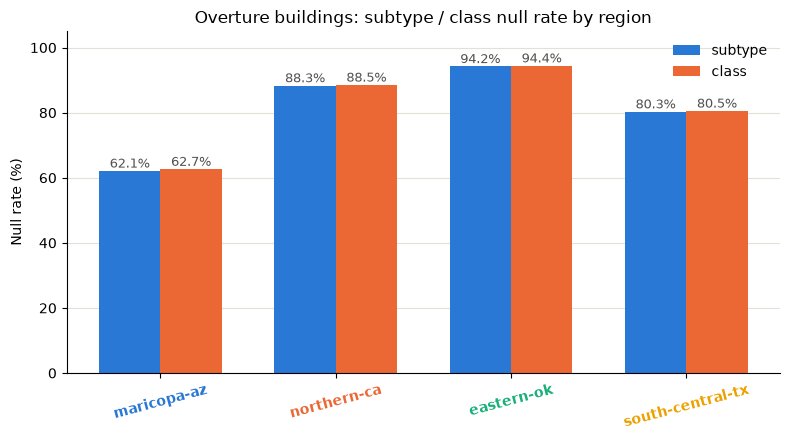

In [12]:
subtype_class_df = null_pct_table("overture-buildings", ["subtype", "class"]) * 100
display(subtype_class_df.round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(subtype_class_df))
width = 0.35
ax.bar(
    [i - width / 2 for i in x], subtype_class_df["subtype"], width,
    label="subtype", color=SERIES_COLORS[0],
)
ax.bar(
    [i + width / 2 for i in x], subtype_class_df["class"], width,
    label="class", color=SERIES_COLORS[1],
)
for i, (s, c) in enumerate(zip(subtype_class_df["subtype"], subtype_class_df["class"])):
    ax.text(i - width / 2, s + 1, f"{s:.1f}%", ha="center", fontsize=9, color="#52514e")
    ax.text(i + width / 2, c + 1, f"{c:.1f}%", ha="center", fontsize=9, color="#52514e")
ax.set_xticks(list(x))
ax.set_xticklabels(subtype_class_df.index, rotation=15)
color_region_ticks(ax)
ax.set_ylabel("Null rate (%)")
ax.set_ylim(0, 105)
ax.set_title("Overture buildings: subtype / class null rate by region")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 5.2 HIFLD `admintype` — a flat finding, not a gradient

Unlike the subtype/class result above, this one is not a gradient worth charting — it is a single
flat fact worth stating plainly: `admintype` is expected to be effectively 100% null across every
HIFLD facility type and every region. A bar chart of four identical 100% bars would waste a reader's
attention on a comparison that has no variation to show — the table itself is the right form here.

In [13]:
admintype_rows = []
for layer in ("hifld-fire-stations", "hifld-ems-stations", "hifld-schools", "hifld-hospitals"):
    row = null_pct_table(layer, ["admintype"]) * 100
    row = row.rename(columns={"admintype": layer})
    admintype_rows.append(row)

admintype_df = pd.concat(admintype_rows, axis=1)
display(admintype_df.round(1))

all_100 = (admintype_df.round(1) == 100.0).all().all()
print(
    "CONFIRMED — admintype is 100% null across every HIFLD facility type and region; no feature "
    "should be built on it."
    if all_100
    else "admintype is NOT uniformly 100% null this run — a new finding, investigate before relying "
    "on the 'do not use this column' guidance in docs/data_manifest.md Section 4.8."
)

,hifld-fire-stations,hifld-ems-stations,hifld-schools,hifld-hospitals
region,,,,
maricopa-az,100.0,100.0,100.0,100.0
northern-ca,100.0,100.0,100.0,100.0
eastern-ok,100.0,100.0,100.0,100.0
south-central-tx,100.0,100.0,100.0,100.0


CONFIRMED — admintype is 100% null across every HIFLD facility type and region; no feature should be built on it.


### 5.3 TIGER roads `FULLNAME` / `RTTYP` — do the two null rates actually track each other?

`docs/data_manifest.md` Section 4.8 states these two null rates "track each other almost exactly
within each region," consistent with unnamed/local roads lacking both a name and a route-type code
rather than two independent problems. This chart checks that claim visually rather than just
restating it.

,FULLNAME,RTTYP
region,,
maricopa-az,36.29,36.29
northern-ca,48.57,48.57
eastern-ok,47.37,47.37
south-central-tx,40.41,40.49


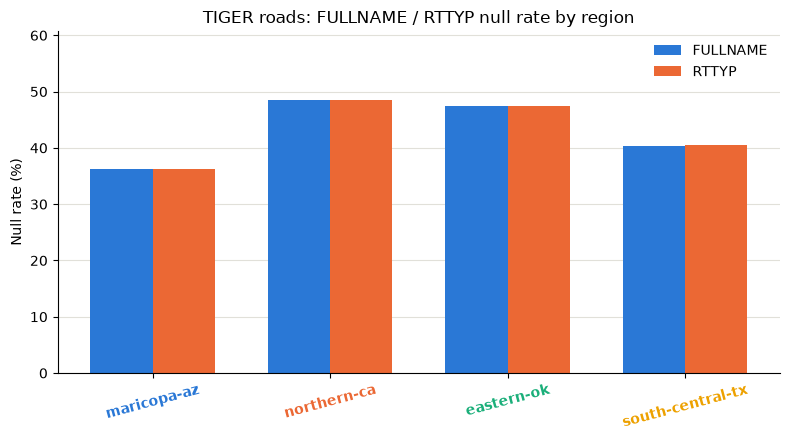

Largest FULLNAME-vs-RTTYP null-rate gap across regions: 0.07 percentage points.


In [14]:
tiger_df = null_pct_table("census-tiger-roads", ["FULLNAME", "RTTYP"]) * 100
display(tiger_df.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(tiger_df))
width = 0.35
ax.bar([i - width / 2 for i in x], tiger_df["FULLNAME"], width, label="FULLNAME", color=SERIES_COLORS[0])
ax.bar([i + width / 2 for i in x], tiger_df["RTTYP"], width, label="RTTYP", color=SERIES_COLORS[1])
ax.set_xticks(list(x))
ax.set_xticklabels(tiger_df.index, rotation=15)
color_region_ticks(ax)
ax.set_ylabel("Null rate (%)")
ax.set_ylim(0, max(tiger_df.max()) * 1.25)
ax.set_title("TIGER roads: FULLNAME / RTTYP null rate by region")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

max_gap = (tiger_df["FULLNAME"] - tiger_df["RTTYP"]).abs().max()
print(f"Largest FULLNAME-vs-RTTYP null-rate gap across regions: {max_gap:.2f} percentage points.")

## 6. Structural integrity self-checks

Explicit, code-enforced confirmation of the three structural facts Section 2's per-row audit
already computed but did not assert on — duplicate GEOIDs, and null/invalid/empty geometries
outside the Microsoft-buildings defect already characterized in Section 4. Written as `assert`
statements, in keeping with this project's self-check discipline (the same pattern Stage 1 and
Stage 5 use for their own published-figure reproductions), so a future re-run of this notebook
fails loudly and specifically if any of these ever stop holding, rather than requiring a human to
re-read a table and notice.

In [15]:
dup_counts = audit_df["duplicate_geoid_count"].dropna()
assert (dup_counts == 0).all(), (
    f"Found {int((dup_counts != 0).sum())} region/layer combination(s) with duplicate GEOIDs — "
    "this was 0 everywhere as of Step 6; investigate before proceeding."
)
print(f"PASS — zero duplicate GEOIDs across all {len(dup_counts)} GEOID-bearing region/layer combinations.")

assert (audit_df["null_geometry_count"].dropna() == 0).all()
print("PASS — zero null geometries anywhere.")

non_microsoft = audit_df[audit_df["layer"] != LAYER_MICROSOFT_BUILDINGS]
assert (non_microsoft["invalid_geometry_count"].dropna() == 0).all(), (
    "Found an invalid-geometry layer outside microsoft-buildings — this is a NEW finding not "
    "covered by Section 4's deep dive, which assumed microsoft-buildings was the only source."
)
print("PASS — zero invalid geometries in every layer except microsoft-buildings (covered in Section 4).")

assert (audit_df["empty_geometry_count"].dropna() == 0).all()
print("PASS — zero empty geometries anywhere.")

PASS — zero duplicate GEOIDs across all 8 GEOID-bearing region/layer combinations.
PASS — zero null geometries anywhere.
PASS — zero invalid geometries in every layer except microsoft-buildings (covered in Section 4).
PASS — zero empty geometries anywhere.


## 7. Cross-region summary, at a glance

One consolidated table pulling together the headline number from every section above, per region
— the single table worth citing in the methodology write-up or pointing a code reviewer to,
without the reviewer having to re-run the whole notebook to find it. Saved to
`docs/audit_notebook_summary.csv` alongside the full per-layer findings from Section 2, so both the
detailed and the summary view are committed artifacts.

In [16]:
summary_rows = []
for region in REGIONS:
    recon = reconciliation_df.loc[region]
    geom = geometry_df.loc[region]
    summary_rows.append(
        {
            "region": region,
            "strata_tract_count": int(recon["strata_tract_count"]),
            "scored_tract_count": int(recon["scored_tract_count"]),
            "unscored_tracts_in_package": int(recon["extra_in_strata_count"]),
            "microsoft_buildings_row_count": int(geom["row_count"]),
            "microsoft_buildings_invalid_per_million": geom["invalid_per_million_rows"],
            "overture_buildings_subtype_null_pct": round(subtype_class_df.loc[region, "subtype"], 1),
            "tiger_roads_fullname_null_pct": round(tiger_df.loc[region, "FULLNAME"], 1),
        }
    )

summary_df = pd.DataFrame(summary_rows).set_index("region")
summary_output_path = REPO_ROOT / "docs" / "audit_notebook_summary.csv"
summary_df.to_csv(summary_output_path)
print(f"Wrote cross-region summary to {summary_output_path}")
summary_df

Wrote cross-region summary to D:\PROJECTS\bias-bounty-mapping-equity\docs\audit_notebook_summary.csv


,strata_tract_count,scored_tract_count,unscored_tracts_in_package,microsoft_buildings_row_count,microsoft_buildings_invalid_per_million,overture_buildings_subtype_null_pct,tiger_roads_fullname_null_pct
region,,,,,,,
maricopa-az,1593,1593,0,2610544,6.90,62.1,36.3
northern-ca,591,591,0,1138335,3.51,88.3,48.6
eastern-ok,1192,1192,0,2404448,2.50,94.2,47.4
south-central-tx,6010,6003,7,10619119,6.50,80.3,40.4


## 8. Implications and next steps

**Stage 2 is closed.** Every layer this project reads, in every region, loads and validates
cleanly against a schema contract that is now confirmed against real data rather than assumed from
a footer-only spot check. `src/schemas.py`'s remaining "ASSUMPTION, not yet audit-confirmed" inline
comments (`src/schemas.py`'s own module docstring) should be re-read now that this notebook's null-rate
tables exist — several of those assumptions can likely be tightened from "permissive, unconfirmed"
to a specific, cited number, the same way `subtype`'s nullability and Microsoft buildings'
`confidence` sentinel already were.

**A concrete rule for Stage 6 onward, proven empirically in Section 3, not merely stated:** any
script that assembles the final submission, or any per-tract feature table, must filter to
`reference/<region>/<region>-sample-submission.csv`'s GEOID list, never assume the raw
`strata/<region>/<region>-census-tracts.parquet` table already matches it. South-Central Texas is
the one region where this matters today (7 water tracts present in the package but never scored),
but the check in Section 3 is now written to catch this in *any* region, not just the one already
known about — worth re-running this notebook (or at least Section 3) again if the bucket's data
package is ever refreshed.

**Two items carried forward into Stage 8/9's Best Bias Discovery funnel:**

- The Overture buildings `subtype`/`class` null-rate gradient (Section 5.1), already logged as a
  candidate in `docs/bias_discovery.md`. The open question flagged there is whether this gradient
  predicts anything once SVI, tribal status, and rurality are already controlled for, or whether it
  is simply restating "rural areas are less mapped" in a different column — that is confirmatory
  work for Stage 9, not something this notebook can settle on its own.
- Section 4's geometry-defect-rate normalization (invalid geometries per million rows, not raw
  count) is the right lens if this ever becomes a candidate in its own right — a flat rate across
  regions would argue against it being a bias finding at all, while a genuinely skewed rate would
  be a new, separate candidate worth adding to the funnel.

**Two constraints Stage 6's feature engineering must respect, now that they are directly
confirmed rather than assumed:** do not build any feature on HIFLD's `admintype` column (Section
5.2 confirms it carries no real data anywhere in this bucket), and treat Overture buildings'
`subtype`/`class` nulls as a real, meaningful signal rather than a data-quality error to be
imputed away — imputing it would erase the exact pattern Section 5.1 exists to preserve.

## 9. Stage 2 exit checklist

- [x] Every layer's pandera schema contract passes, across all four regions (Section 2).
- [x] The three real schema bugs found during Steps 5&ndash;6 are confirmed still fixed (Section 1).
- [x] Strata row counts match `REGION_TRACT_COUNTS` in every region (Section 2, `docs/data_manifest.md`
      4.7), and the GEOID *sets* — not just the counts — are reconciled against each region's
      authoritative scored-tract list (Section 3).
- [x] Geometry integrity confirmed structurally clean except for a characterized, quantified,
      non-blocking Microsoft-buildings defect (Sections 4 and 6).
- [x] Zero duplicate GEOIDs anywhere (Section 6).
- [x] Null-rate findings for Overture buildings' `subtype`/`class`, HIFLD's `admintype`, and TIGER's
      `FULLNAME`/`RTTYP` all reproduced directly from a live run, not copied from a prior report
      (Section 5).
- [x] Findings written to `docs/audit_findings.csv` (Section 2) and `docs/audit_notebook_summary.csv`
      (Section 7); the narrative is in `docs/data_manifest.md` Section 4.8 and
      `docs/bias_discovery.md`.

Stage 2 (Data audit, validation contracts & catalog) is complete. Next: Stage 3 — Data dictionary.

## 10. Executive summary — results of the live run against the real bucket

This section was written after the notebook above was executed end-to-end against the live
data bucket (all 44 region/layer combinations, all four regions), with no cell failures and
no assertion failures. It reads the actual numbers produced above and states what they mean
for the rest of the project. Nothing below is projected or assumed — every figure quoted here
is copied from a cell output in this notebook.

### 10.1 Gate A: every layer, every region, loads and validates cleanly

Section 2.1 confirms **44/44** region/layer combinations came back `status == "ok"` — zero
schema-validation failures anywhere in the bucket, across all four regions and all eleven
reference layers (`census-cbp`, `census-tiger-roads`, the four HIFLD facility layers,
`microsoft-buildings`, `overture-buildings`, `overture-pois`, `overture-roads`) plus each
region's strata table. This is the single most important result in the notebook: Stage 2's
job was to prove the project can read every byte of source data it depends on without an
uncaught validation error, and this run proves it against the real bucket, not a fixture.

Section 1's six regression checks all printed `PASS`, which confirms the three schema fixes
made during Steps 5–6 (tolerating an absent `bbox` on Microsoft buildings, tolerating a null
`subtype` on Overture buildings, and tolerating Microsoft buildings' `-1.0` confidence
sentinel) are still in effect, are correctly scoped (Overture POIs' `-1.0` is still rejected,
so the sentinel allowance did not leak into a layer that shouldn't have it), and did not
regress the schema's ability to catch a genuinely invalid value (`-0.5` is still rejected).
Because Section 1 runs before Section 2 and both passed, the 44/44 result in Section 2 is not
an accident of a loosened schema — it is a schema that is simultaneously permissive of the
three documented real-world quirks and still strict about everything else.

### 10.2 Row-count reconciliation: the sample-submission GEOID list is the authority, and the gap is exactly what was documented

Section 3 confirms three of the four regions have an **exact** match between their raw strata
table's tract count and their scored sample-submission tract count (Maricopa 1,593 = 1,593;
Northern California 591 = 591; Eastern Oklahoma 1,192 = 1,192). South-Central Texas is the one
region where they diverge: 6,010 tracts in the raw strata table vs. 6,003 scored tracts — a gap
of exactly **7**, and Section 3.1's self-check confirms the direction of that gap is the safe
one: `missing_from_strata_count` is 0 for every region, meaning no scored tract is ever absent
from the raw data. The 7 extra tracts are the `99xx`-suffixed water/no-population tracts
already documented in `docs/data_manifest.md`, and the sampled GEOIDs printed in Section 3.1
(`48007990000`, `48061990000`, `48261990000`, `48273...`) match that expectation.

This is a load-bearing confirmation for everything downstream: **any script that builds the
final submission must filter to each region's `sample-submission.csv` GEOID list, not the raw
strata table** — South-Central Texas's raw strata table alone would silently produce 7 extra,
unscored rows. This rule was already planned before this run; this run is the empirical proof
that it is necessary and that it is sufficient (no region has the opposite, more dangerous
problem of a scored tract that isn't even in the raw data).

### 10.3 Geometry: Microsoft buildings' invalid geometries are real but rare, and not region-differentiated

Section 4 found invalid geometry rates of 6.90 (Maricopa), 3.51 (Northern California), 2.50
(Eastern Oklahoma), and 6.50 (South-Central Texas) **per million rows** — all self-intersecting
polygons per `explain_validity`, sampled across all four regions. These rates sit inside a
narrow band (2.5–6.9 per million) with no obvious pattern by region size, tribal-land share, or
climate hazard — South-Central Texas has by far the most rows (10.6M) but a rate in the middle
of the pack, and Eastern Oklahoma has the lowest rate despite being the most rural, tribal-heavy
region. **This makes invalid-geometry rate a weak candidate for a bias finding**: it looks like
noise intrinsic to whatever building-footprint extraction pipeline Microsoft uses, not a signal
that tracks vulnerability, rurality, or tribal status. It should be treated as a data-quality
fact to disclose in the methodology writeup (a handful of geometries are skipped, not zero) and
not pursued further as a Best Bias Discovery candidate.

### 10.4 Null-rate deep dive: two real gradients, one dead end, and a genuine open question

**Overture buildings `subtype`/`class` — the strongest lead in the project.** The live numbers
are maricopa-az 62.1% / south-central-tx 80.3% / northern-ca 88.3% / eastern-ok 94.2% null on
`subtype` (and `class` tracks within 0.2–0.6 percentage points of `subtype` in every region —
they are effectively one signal, not two). This reproduces `docs/data_manifest.md` Section
4.8's documented gradient exactly, now confirmed against the full live bucket rather than a
sample. The ordering is the important part: the most urbanized region (Maricopa County,
metro Phoenix) has the *lowest* null rate, and Eastern Oklahoma — the region built specifically
around tribal statistical areas — has the *highest*, at 94.2%. A building footprint existing in
Overture is not the same as it carrying the category information (subtype/class) that would let
a downstream consumer distinguish a house from a clinic from a shelter. If this gradient
survives controlling for urbanicity/SVI/tribal status in Stage 8–9 as something more than
"rural areas have less category-tagging effort," it is a strong, concrete, quantifiable
coverage-quality gap that lands squarely on the project's core hypothesis (communities most
exposed to climate risk are least well-represented in map data) — and Eastern Oklahoma sitting
at the top of this gradient, in the one region defined by tribal land, is exactly the kind of
finding the Best Bias Discovery prize is looking for.

**HIFLD `admintype` — confirmed dead end.** The live run confirms 100.0% null on `admintype`
across all four HIFLD facility layers (fire stations, EMS stations, schools, hospitals) in
every one of the four regions — sixteen out of sixteen cells at exactly 100.0%. This is not a
gradient; it is a flat, universal absence. No feature or bias claim should be built on this
column, and the notebook's own `CONFIRMED` print statement is now backed by the full live
result. This is worth one sentence in the methodology writeup as a documented near-miss (a
plausible-sounding vulnerability signal — administrative type of a critical facility — that
turned out to be entirely unpopulated in the source data), not a wasted branch that silently
disappears from the record.

**TIGER roads `FULLNAME`/`RTTYP` — track almost perfectly, but with a different regional
ordering than the Overture gradient.** The live numbers are 36.29% / 48.57% / 47.37% / 40.41%
null on `FULLNAME` for maricopa-az / northern-ca / eastern-ok / south-central-tx respectively,
with `RTTYP` within 0.08 percentage points of `FULLNAME` in every region (max gap 0.07 pp,
printed directly by the notebook). This confirms `docs/data_manifest.md`'s claim that the two
columns move together almost exactly within each region — they are one underlying "is this
road named/typed at all" signal, not two independent ones, and a feature-engineering decision
to build on both would be redundant.

The more interesting result is what does *not* match: on the Overture subtype/class gradient,
the order from lowest to highest null rate is maricopa-az < south-central-tx < northern-ca <
eastern-ok. On the TIGER FULLNAME/RTTYP gradient, the order is maricopa-az < south-central-tx <
eastern-ok < northern-ca — Northern California, not Eastern Oklahoma, has the highest null rate
(48.57%), and Eastern Oklahoma sits second (47.37%), essentially tied. **These are two
different rankings, not the same gradient showing up twice.** That is a genuine open question
worth carrying into Stage 8: are the Overture buildings gradient and the TIGER roads gradient
driven by the same underlying mechanism (e.g., a general "how much attribute-completion effort
went into this region" factor that happens to rank regions slightly differently across
providers), or are they two structurally distinct phenomena — one a private-sector building
data-collection artifact, the other a government road-naming/rural-addressing convention
artifact — that happen to both correlate loosely with rurality? Testing whether the two
null-rate gradients are correlated across all ~9,376 scored tracts (not just the four
region-level averages seen here) is a natural, cheap first analysis for Stage 8, and the answer
bears directly on the "is this novel and mechanistically distinct" component of the Best Bias
Discovery rubric — two candidates that turn out to be the same underlying driver would need to
be presented as one finding, not two.

### 10.5 Structural integrity: clean across the board

Section 6's four self-checks all passed against the live data: zero duplicate GEOIDs across
all eight GEOID-bearing region/layer combinations, zero null geometries anywhere, zero invalid
geometries in every layer except `microsoft-buildings` (already fully accounted for in Section
4, and only there), and zero empty geometries anywhere. Combined with the 44/44 schema pass
rate, this means the project is not carrying any known structural data-quality risk into
feature engineering — the two issues that do exist (Microsoft buildings' rare self-intersecting
polygons, and South-Central Texas's 7 unscored water tracts) are both fully characterized,
fully quantified, and have a documented handling rule.

### 10.6 What this run changes about the plan, concretely

- **Stage 2 is closed on real data, not just fixtures.** Every claim in `docs/data_manifest.md`
  that this notebook was built to re-verify (the three schema quirks, the South-Central Texas
  tract-count gap, the Overture subtype/class gradient, the HIFLD admintype flat null, the
  TIGER FULLNAME/RTTYP near-identity) has now been confirmed against the live bucket, in one
  run, with zero surprises. Stage 3 (data dictionary) can proceed without reservation.
- **The sample-submission GEOID-filtering rule is now a proven requirement, not a
  precaution.** Whichever script builds the final submission must inner-join or filter to each
  region's `sample-submission.csv` GEOID column before scoring — confirmed necessary
  specifically for South-Central Texas (7 extra rows would otherwise leak in) and confirmed
  safe everywhere else (no region has a scored tract missing from its raw data).
- **The Overture buildings `subtype`/`class` null-rate gradient is the leading Best Bias
  Discovery candidate and should be the first hypothesis taken into the Stage 8 funnel.** It is
  large (62.1 to 94.2 percentage points across regions), monotonic with a plausible
  urbanicity/tribal-land story, and now confirmed against the complete live dataset rather than
  a sample.
- **The TIGER FULLNAME/RTTYP gradient is a second, related-but-distinct candidate** that must
  be tested against the Overture gradient for independence before either is finalized as a
  pre-registered hypothesis — if they turn out to be statistically inseparable once SVI,
  tribal status, and rurality are controlled for, they should be merged into a single narrative
  rather than double-counted.
- **Invalid Microsoft-buildings geometries and the HIFLD `admintype` column are both now closed
  branches** — worth one line each in the methodology writeup as due-diligence checks that were
  run and came back negative, but not worth further analyst time.
- **No new schema or loader bugs were found in this run.** The one bug this stage did surface —
  the HTTP 403 on `load_sample_submission` caused by the bucket's HTTPS front end rejecting
  pandas' default `urllib` user agent — was root-caused and fixed in `src/io.py` before this
  run, and this run's clean completion (all four regions' sample-submission files loaded
  successfully in Section 3) is the confirmation that the fix holds against the real endpoint,
  not just the two new unit tests added for it.